In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla Sales and Price Prediction using Machine Learning

## Objective
Build an end-to-end Machine Learning pipeline for Tesla sales/price data including:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [4]:
df =  pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Data Cleaning

In [7]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
print(df.shape)

(2640, 12)


# Exploratory Data Analysis

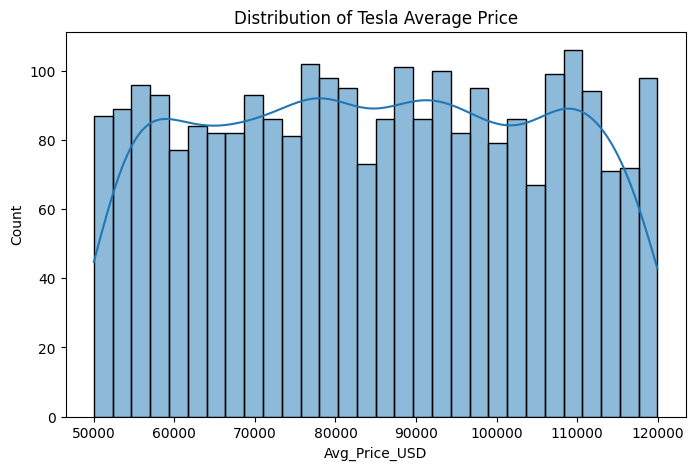

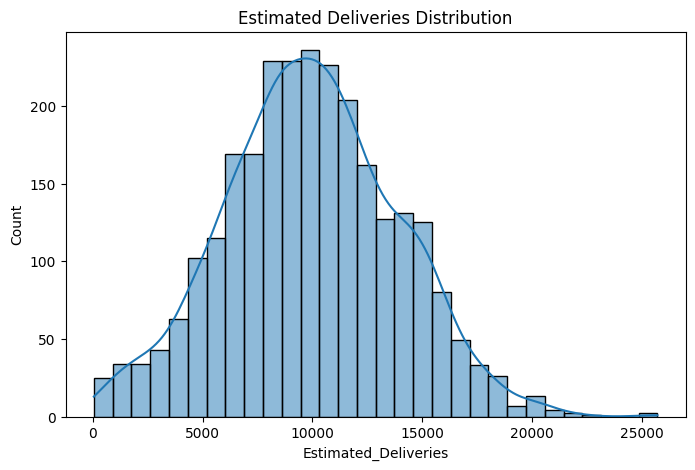

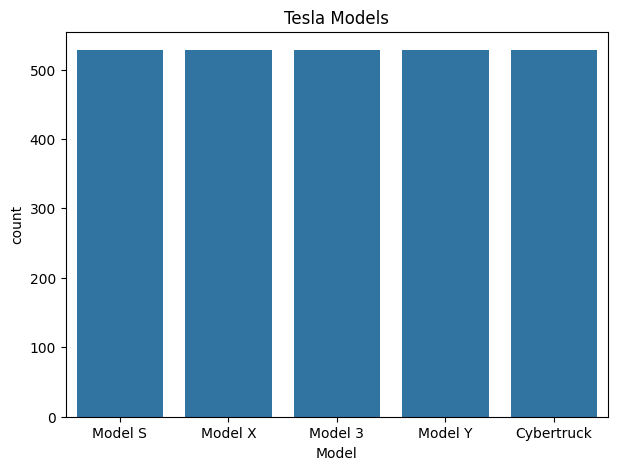

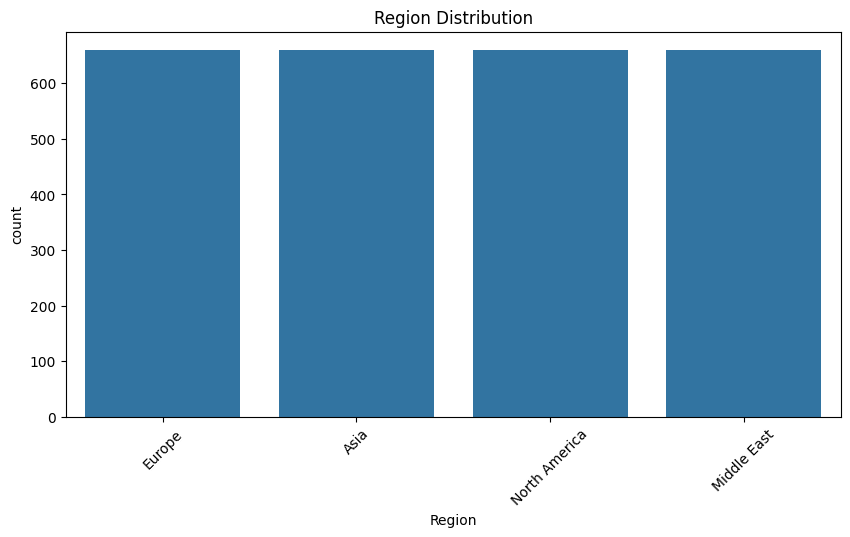

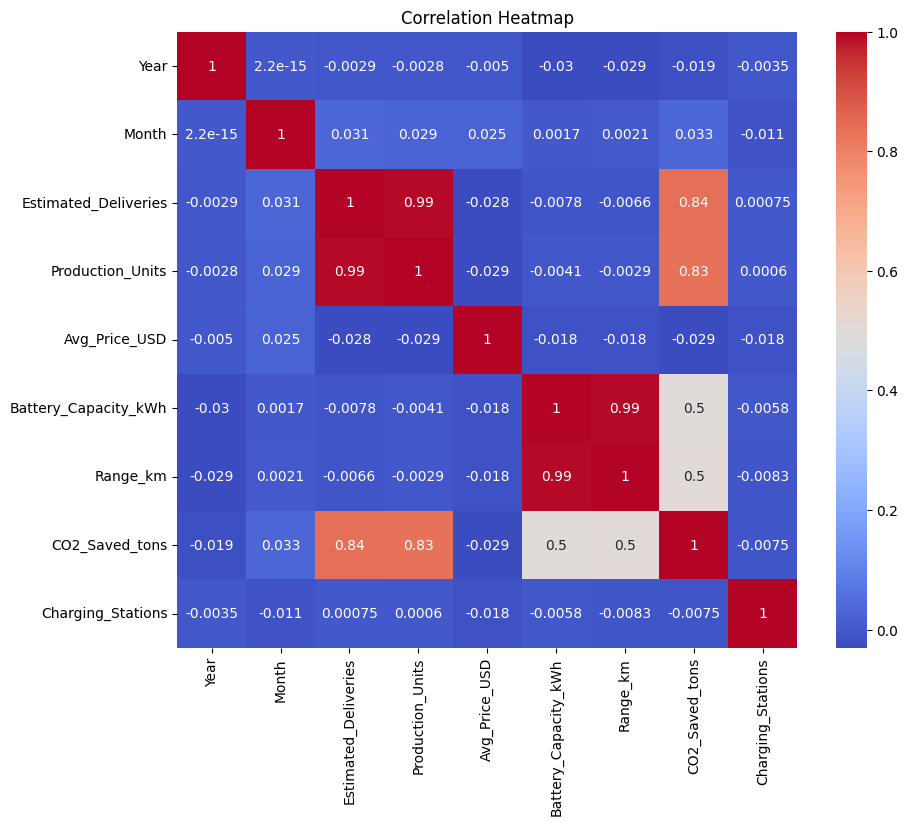

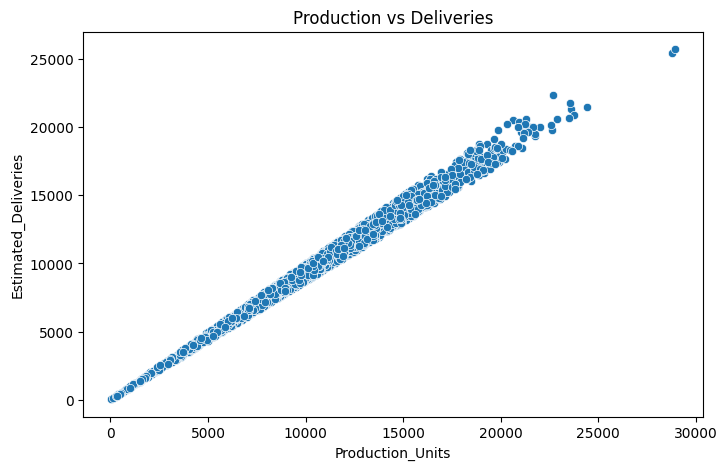

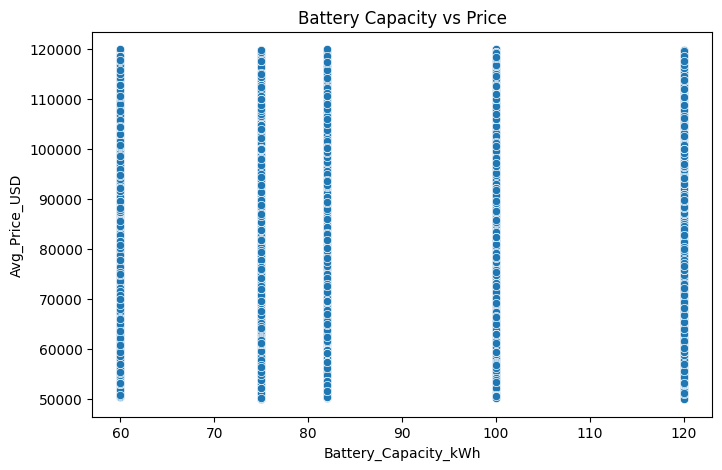

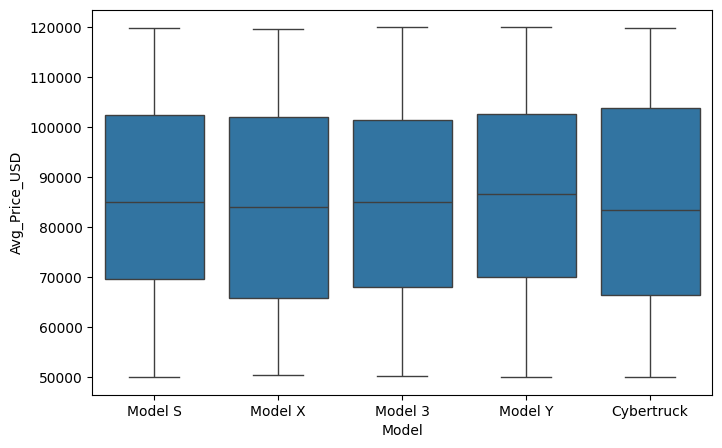

In [11]:
#Distribution of Tesla Average Price
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'], bins=30, kde=True)
plt.title("Distribution of Tesla Average Price")
plt.show()


#Estimated Deliveries Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title("Estimated Deliveries Distribution")
plt.show()




#Tesla Models
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Model')
plt.title("Tesla Models")
plt.show()


#Region Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Region')
plt.xticks(rotation=45)
plt.title("Region Distribution")
plt.show()



#HeatMAP
plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()



#Production vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)
plt.title("Production vs Deliveries")
plt.show()




#Battery Capacity vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Battery_Capacity_kWh',
    y='Avg_Price_USD',
    data=df
)
plt.title("Battery Capacity vs Price")
plt.show()




plt.figure(figsize=(8,5))
sns.boxplot(
    x='Model',
    y='Avg_Price_USD',
    data=df
)
plt.show()

# Feature Engineering

In [12]:
# Create Quarter from Month
df['Quarter'] = ((df['Month'] - 1) // 3) + 1
# Production Efficiency
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)
# Price per Kilometer of Range
df['Price_per_km'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Production_Efficiency,Price_per_km
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2,0.984600,131.923679
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,1,0.911864,142.022032
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,1,0.915334,245.598583
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,1,0.896594,125.414199
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,4,0.914087,173.747020


In [13]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Quarter',
       'Production_Efficiency', 'Price_per_km'],
      dtype='object')

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = ['Region', 'Model', 'Source_Type']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Production_Efficiency,Price_per_km
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2,0.984600,131.923679
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,1,0.911864,142.022032
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,1,0.915334,245.598583
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,1,0.896594,125.414199
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,4,0.914087,173.747020


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   2640 non-null   int64  
 1   Month                  2640 non-null   int64  
 2   Region                 2640 non-null   int64  
 3   Model                  2640 non-null   int64  
 4   Estimated_Deliveries   2640 non-null   int64  
 5   Production_Units       2640 non-null   int64  
 6   Avg_Price_USD          2640 non-null   float64
 7   Battery_Capacity_kWh   2640 non-null   int64  
 8   Range_km               2640 non-null   int64  
 9   CO2_Saved_tons         2640 non-null   float64
 10  Source_Type            2640 non-null   int64  
 11  Charging_Stations      2640 non-null   int64  
 12  Quarter                2640 non-null   int64  
 13  Production_Efficiency  2640 non-null   float64
 14  Price_per_km           2640 non-null   float64
dtypes: f

In [16]:
X = df.drop('Avg_Price_USD', axis=1)
y = df['Avg_Price_USD']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(2112, 14)
(528, 14)


# Linear Regression Model

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2 Score :", r2_score(y_test, pred_lr))

MAE : 4990.204602868339
RMSE : 6138.75588112334
R2 Score : 0.9000714635541078


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [21]:
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2 Score :", r2_score(y_test, pred_rf))

MAE : 646.9214087121204
RMSE : 864.1776874689554
R2 Score : 0.998019682167861


In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.900071,6138.755881
1,Random Forest,0.998020,864.177687


# Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [24]:
best_pred = best_model.predict(X_test)

print("R2 Score :", r2_score(y_test, best_pred))
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))

R2 Score : 0.9980423167964958
MAE : 639.7933070075718
RMSE : 859.2248068985781


In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
13,Price_per_km,0.678451
7,Range_km,0.267010
6,Battery_Capacity_kWh,0.051906
12,Production_Efficiency,0.000446
10,Charging_Stations,0.000418
0,Year,0.000289
8,CO2_Saved_tons,0.000238
1,Month,0.000236
5,Production_Units,0.000224
4,Estimated_Deliveries,0.000203


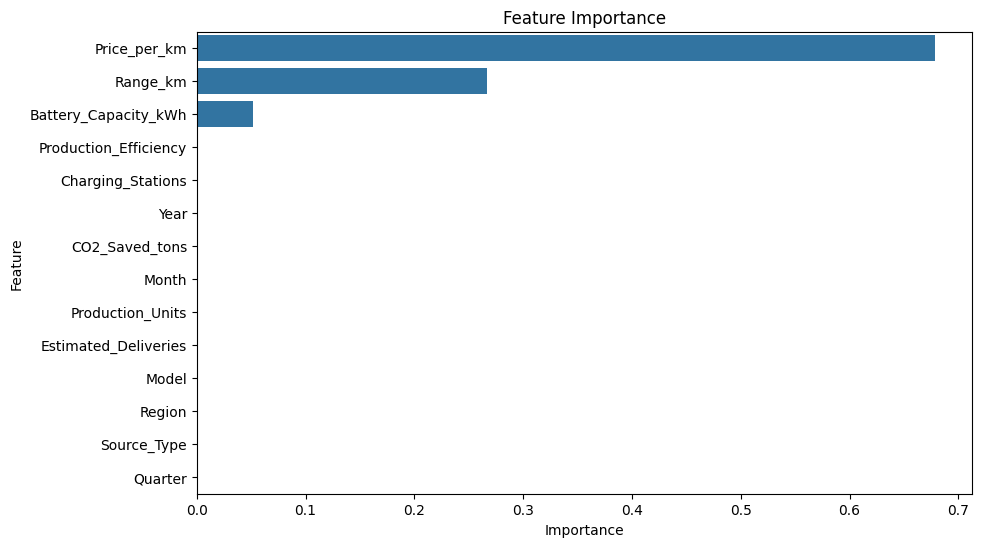

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [27]:
df_ts = df.copy()

df_ts['Date'] = pd.to_datetime(
    dict(
        year=df_ts['Year'],
        month=df_ts['Month'],
        day=1
    )
)
df_ts = df_ts.sort_values('Date')

In [28]:
df_ts.set_index('Date', inplace=True)

In [29]:
price_series = df_ts['Avg_Price_USD'].resample('M').mean()

/tmp/ipykernel_16/2238617220.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  price_series = df_ts['Avg_Price_USD'].resample('M').mean()


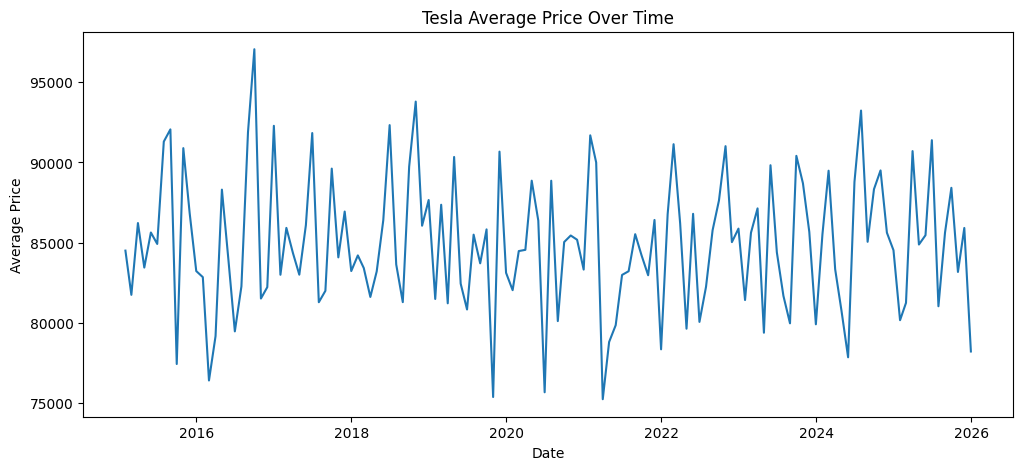

In [30]:
plt.figure(figsize=(12,5))
plt.plot(price_series)
plt.title("Tesla Average Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.show()

In [31]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(price_series, order=(2,1,2))
model_fit = model.fit()

In [32]:
forecast = model_fit.forecast(steps=12)
print(forecast)

2026-01-31    80024.783952
2026-02-28    80517.661157
2026-03-31    80252.320894
2026-04-30    79900.157154
2026-05-31    79742.736062
2026-06-30    79751.101727
2026-07-31    79810.035302
2026-08-31    79848.528327
2026-09-30    79855.645013
2026-10-31    79847.657299
2026-11-30    79839.658658
2026-12-31    79836.744288
Freq: ME, Name: predicted_mean, dtype: float64


/tmp/ipykernel_16/2973026015.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(


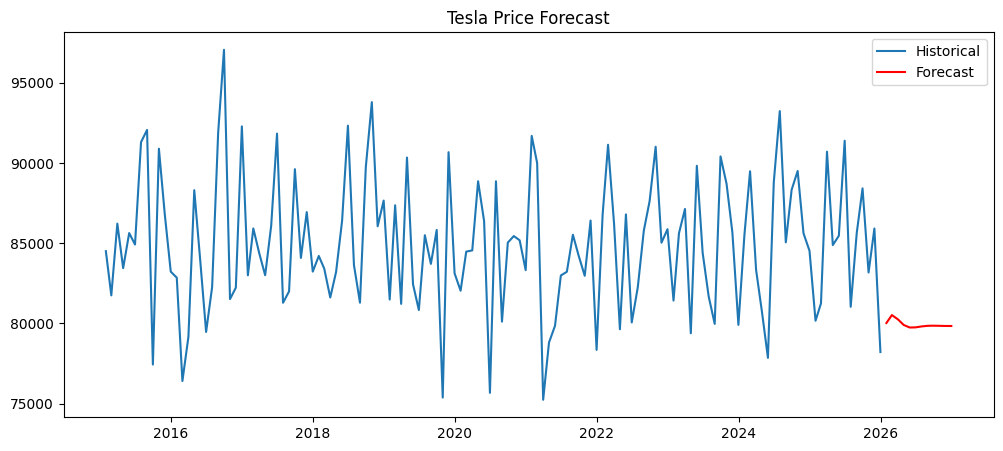

In [33]:
plt.figure(figsize=(12,5))
plt.plot(price_series, label="Historical")

forecast_index = pd.date_range(
    start=price_series.index[-1],
    periods=13,
    freq='M'
)[1:]
plt.plot(
    forecast_index,
    forecast,
    color='red',
    label='Forecast'
)
plt.legend()
plt.title("Tesla Price Forecast")
plt.show()

# Conclusion
- Cleaned and preprocessed Tesla sales dataset
- Performed exploratory data analysis using statistical summaries and visualizations
- Created additional features to improve model performance
- Encoded categorical variables
- Built Linear Regression and Random Forest Regression models
- Improved the Random Forest model using GridSearchCV
- Analyzed feature importance
- Forecasted future Tesla prices using ARIMA time series forecasting
- Successfully developed an end-to-end machine learning pipeline